I will compare GTLS and TLS on Kepler Data.

/home/farxi/.local/lib/python3.8/site-packages/lightkurve/search.py:414: LightkurveWarning: Warning: 4 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


<AxesSubplot: xlabel='Time - 2454833 [BKJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

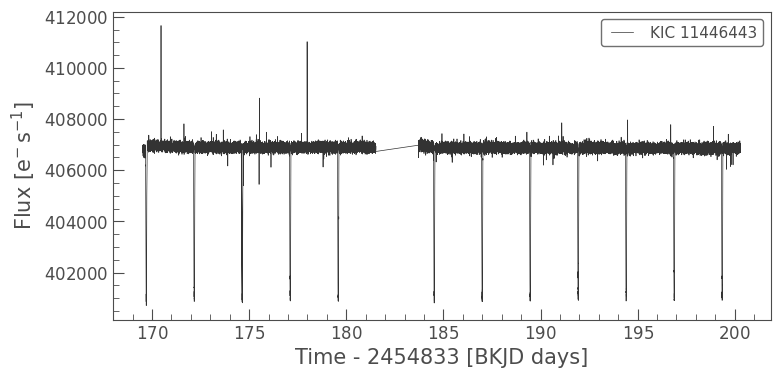

In [74]:
import lightkurve as lk
import matplotlib.pyplot as plt
%matplotlib inline
from transitleastsquares import transitleastsquares
from gputls import gtls

search_result_q2 = lk.search_lightcurve('KIC 11446443', author='Kepler', quarter=2)
lc = search_result_q2.download()
lc.plot()

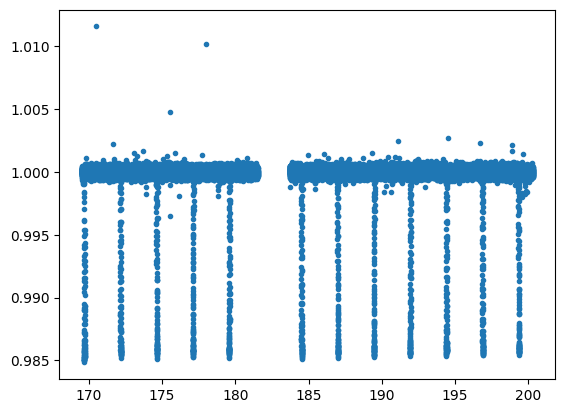

In [75]:
from wotan import flatten
import numpy as np
time = lc.time.to_value('bkjd', 'long')
flux = lc.flux.unmasked.value
flux = flux / np.nanmedian(flux)
flatten_lc, trend_lc = flatten(time, flux, window_length=0.5, method='biweight', return_trend=True)
plt.plot(time, flatten_lc, '.')

In [76]:
model = gtls(t = time, y = flux)
gtlsResult = model.power()
print('period', gtlsResult.period, 'duration', gtlsResult.duration, 'depth', gtlsResult.depth, 'T0', gtlsResult.T0,'SDE', gtlsResult.SDE)

GPU Transit Least Squares GTLS 0.2.0 (March 2023)
Creating model cache for 39 durations
Searching 41816 data points, 2868 periods from 0.601 to 15.386 days
TotalIter 23
10 / 23 bulk periods calculated
20 / 23 bulk periods calculated
period 2.469877670406955 duration 0.0555030287763008 depth 0.9868741603568196 T0 169.70716819442185 SDE 49.16803


In [77]:
model = transitleastsquares(time, flux)
results = model.power()
print('period', results.period, 'duration', results.duration, 'depth', results.depth, 'T0', results.T0,'SDE', results.SDE)

Transit Least Squares TLS 1.0.31 (22 Nov 2021)
Creating model cache for 39 durations
Searching 41816 data points, 2868 periods from 0.601 to 15.386 days
Using all 12 CPU threads


100%|██████████| 2868/2868 periods | 00:46<00:00


Searching for best T0 for period 2.46988 days
period 2.469877670406955 duration 0.05550302877630075 depth 0.9868734558060456 T0 169.70932241400206 SDE 49.16627945608454
